# Lab 7b: Understanding a Small Boltzmann Machines

In this lab, we will explore some questions surrounding the sampling and stationary distribution of a _small_ Boltzmann machine. In particular, we'll look at one of the key limitations of any training approach, namely requiring convergence to a stationary distribution for each training iteration.

> __Learning Objectives__
>
> By the end of this lab, you should be able to:
> * __Sample a Boltzmann machine:__ Implement Gibbs sampling to generate state configurations from a Boltzmann machine. Explain how the inverse temperature parameter $\beta$ changes exploration versus concentration in the sampled states.
> * __Compute the stationary distribution:__ Calculate the exact Boltzmann distribution for a small network by enumerating all configurations and computing the partition function. Verify that the resulting probabilities are normalized and consistent with the energy values.
> * __Compare empirical and theoretical distributions:__ Estimate the empirical distribution from samples and compare it to the theoretical stationary distribution. Use probability values and ranks to judge whether the sampler is approaching stationarity.


Let's get started!
___

## Background: What is a Boltzmann Machine?
A [Boltzmann Machine](https://en.wikipedia.org/wiki/Boltzmann_machine) consists of a set of binary units (neurons, nodes, vertices, etc.) that are fully connected, with no self-connections. Formally, [a Boltzmann Machine](https://en.wikipedia.org/wiki/Boltzmann_machine) $\mathcal{B}$ is a fully connected _undirected weighted graph_ defined by the tuple $\mathcal{B} = \left(\mathcal{V},\mathcal{E}, \mathbf{W},\mathbf{b}, \mathbf{s}\right)$.
* __Units__: Each unit (vertex, node, neuron) $v_{i}\in\mathcal{V}$ has a binary state (`on` or `off`) and a bias value 
$b_{i}\in\mathbb{R}$, where $b_{i}$ is the bias of the node $v_{i}$. The bias vector $\mathbf{b}\in\mathbb{R}^{|\mathcal{V}|}$ is the vector of bias values for all nodes in the network. 
* __Edges__: Each edge $e\in\mathcal{E}$ has a weight. The weight of the edge connecting $v_{i}\in\mathcal{V}$ and $v_{j}\in\mathcal{V}$, is denoted by $w_{ij}\in\mathbf{W}$, where the weight matrix $\mathbf{W}\in\mathbb{R}^{|\mathcal{V}|\times|\mathcal{V}|}$ is symmetric, i.e. $w_{ij} = w_{ji}$ and $w_{ii} = 0$ (no self loops). The weights $w_{ij}\in\mathbb{R}$ determine the strength of the connection between the two nodes. 
* __States__: The state of each node is represented by a binary vector $\mathbf{s}\in\mathbb{R}^{|\mathcal{V}|}$, where $s_{i}\in\{-1,1\}$ is the state of node $v_{i}$. When $s_{i} = 1$, the node is `on`, and when $s_{i} = -1$, the node is `off`. The set of all possible state _configurations_ is denoted by $\mathcal{S} \equiv \left\{\mathbf{s}^{(1)},\mathbf{s}^{(2)},\ldots,\mathbf{s}^{(N)}\right\}$, where $N$ is the number of possible state configurations, or $N = 2^{|\mathcal{V}|}$ for binary units.

Suppose we have values for the weights $\mathbf{W}$ and biases $\mathbf{b}$ of the Boltzmann machine. One of the key questions we can ask is: how can we generate samples from this Boltzmann machine?

### Sampling algorithm
One of the key theoretical ideas of [the Boltzmann machine](https://en.wikipedia.org/wiki/Boltzmann_machine) is that the samples generated from it are distributed according to [the Boltzmann distribution](https://en.wikipedia.org/wiki/Boltzmann_distribution). Let's test this idea. 

To generate samples from a Boltzmann Machine, let us consider the following algorithm (Gibbs sampling): 

__Initialize__ the weights $\mathbf{W}$ and biases $\mathbf{b}$ of the Boltzmann Machine. Provide an initial state $\mathbf{s}^{(0)}$ of the network, and a system temperature $\beta$.

For each turn $t=1,2,\dots,T$:
1. For each node $v_{i}\in\mathcal{V}$:
    1. Compute the total input $h_{i}^{(t)}$ to node $v_{i}$ using $h_{i}^{(t)} = \sum_{j\in\mathcal{V}} w_{ij}s_{j}^{(t-1)} + b_{i}$.
    2. Compute the probability of the _next_ state $s_{i}^{(t)} = 1$ using the logistic function $P(s_{i}^{(t)} = 1 \mid s_{\lnot{i}}) = \left(1+\exp(-2\beta\cdot{h}_{i}^{(t)})\right)^{-1}$ for node $v_{i}$. The factor of $2$ arises because flipping $s_{i}$ between $\{-1,+1\}$ changes the energy by $2h_{i}^{(t)}$. The probability of $s_{i}^{(t)} = -1$ is given by $P(s_{i}^{(t)} = -1 \mid s_{\lnot{i}}) = 1 - P(s_{i}^{(t)} = 1 \mid s_{\lnot{i}})$.
    3. Sample the _next_ state of node $v_{i}$ from a [Bernoulli distribution](https://en.wikipedia.org/wiki/Bernoulli_distribution) with parameter $p = P(s_{i}^{(t)} = 1 \mid s_{\lnot{i}})$.
2. Store the state vector $\mathbf{s}^{(t)}$ of the network at turn $t$, and proceed to the next turn.


We've implemented this algorithm [in the `sample(...)` method](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/boltzmann/#VLDataScienceMachineLearningPackage.sample-Tuple{MySimpleBoltzmannMachineModel,%20Vector{Int64}}). Let's use it to generate samples from a small Boltzmann machine and see how the empirical distribution of the samples compares to the theoretical Boltzmann distribution.
___

## Setup, Data, and Prerequisites
We set up the computational environment by including the `Include.jl` file, loading any needed resources, such as sample datasets, and setting up any required constants.

> __Environment Setup with Include.jl__
>
> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

In addition to standard Julia libraries, we'll also use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl). Check out [the documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/) for more information on the functions, types, and data used in this material.

### Constants 
Set some constants that we will use later. Please look at the comments in the code for more details on each constant's permissible values, units, etc. 

In [2]:
number_of_nodes = 3; # number of nodes in the system
β = 0.1; # inverse temperature parameter for the system (big: cold, small: hot)
number_of_turns = 10000; # number of turns that we take in the simulation

### Implementation
We need a helper function to compute the energy of a given state configuration. We've implemented this in the `energy(...)` method below.

> The `energy(...)` method computes the energy of a state configuration $\mathbf{s}$ using the formula $E(\mathbf{s}) = -\frac{1}{2}\mathbf{s}^{\top}\mathbf{W}\mathbf{s} - \mathbf{b}^{\top}\mathbf{s}$. The first term captures pairwise interactions between nodes (weighted by $\mathbf{W}$), and the second term captures the contribution of each node's bias.

In [3]:
function energy(model::MySimpleBoltzmannMachineModel, s::Vector{Int})::Float64

    # initialize -
    W = model.W; # weight matrix
    b = model.b; # bias vector
    energy = -(1/2)*dot(s, W*s) - dot(b, s); # compute the energy of the state

    # return -
    return energy;
end

energy (generic function with 1 method)

___

## Task 1: Estimate the stationary distribution for a small system
In this task, we sample the dynamics of a three-state [Boltzmann machine](https://en.wikipedia.org/wiki/Boltzmann_machine) and explore a key question: can we estimate the stationary distribution of the Boltzmann machine from sample? 

We'll do this with a straightforward three-node Boltzmann machine (small enough to compute all the configurations required by the partition function) using the Gibbs sampling algorithm described above.

First, let's set up our model of the Boltzmann machine with some random parameters that we hypothetically learned from data. For now, let's save the random weights in the `W::Array{Float64,2}` matrix and the random biases in the `b::Array{Float64,1}` vector.

In [4]:
W,b = let 
    
    # initialize some random weights and biases
    W = 2*randn(number_of_nodes, number_of_nodes);
    b = randn(number_of_nodes);

    # subract the mean from the weights (no self connections)
    W = W - diagm(diag(W));

    # return -
    W, b
end;

__Model__: Next, let's build a model of the test Boltzmann machine. We'll use [the `MySimpleBoltzmannMachineModel` struct](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/boltzmann/#VLDataScienceMachineLearningPackage.MySimpleBoltzmannMachineModel) to represent the machine; we build an instance of this type [using a `build(...)` method](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/factory/). The struct will have `W::Array{Float64,2}` and `b::Array{Float64,1}` fields that we set when we build an instance of the model.

In [5]:
model = build(MySimpleBoltzmannMachineModel, (
    W = W,
    b = b,
));

Next, let's sample the dynamics of the Boltzmann machine using the Gibbs sampling algorithm described above. We've implemented the Gibbs sampling approach in [the `sample(...)` method](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/boltzmann/#VLDataScienceMachineLearningPackage.sample-Tuple{MySimpleBoltzmannMachineModel,%20Vector{Int64}}) which implements the simple Gibbs sampling procedure described above.
> The [`sample(...)` method](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/boltzmann/#VLDataScienceMachineLearningPackage.sample-Tuple{MySimpleBoltzmannMachineModel,%20Vector{Int64}}) takes a [`MySimpleBoltzmannMachineModel` instance](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/boltzmann/#VLDataScienceMachineLearningPackage.MySimpleBoltzmannMachineModel), an initial state vector `sₒ::Array{Int,1}`, the number of turns `T::Int`, and a system (inverse) temperature `β::Float64`. The method returns an array of samples `S::Array{Int,2}` of size `N` $\times$ `T,` where `N` is the number of nodes in the Boltzmann machine and `T` is the number of turns. 

The code to generate the configurations relies on [our old friend, the `digits(...)` function](https://docs.julialang.org/en/v1/base/numbers/#Base.digits), which converts an integer to a vector of digits in a specified base. We use this function to generate all possible binary configurations of the nodes in the Boltzmann machine, which correspond to the different states of the system.

> __How are we generating the configuration vectors?__
>
> We generate configuration vectors by counting in binary from $0$ to $2^N - 1$, where $N = \texttt{number\_of\_nodes}$. For each integer $i$, `digits(i, base=2, pad=N)` gives an $N$-bit vector, $2x - 1$ maps bits $\{0,1\}$ to spins $\{-1,+1\}$, and `reverse` fixes the bit order to match node indexing. This gives one unique spin configuration $s_i \in \{-1,+1\}^N$ for each integer $i$. 

What's in the `S::Array{Int,2}` array? Each column `S[:,t]` is the state vector of the network at turn `t`, i.e., `S[:,t] == s^(t)`.

In [6]:
S, energy_state_array = let

    # initialize the system
    N = 2^number_of_nodes; # how many configurations do we have
    energy_state = zeros(N); # energy of each state
    
    for i ∈ 0:(N - 1)
        sᵢ = digits(i, base = 2, pad = number_of_nodes) |> x -> 2*x .- 1 |> reverse # convert integer to binary state vector

        # uncomment me to see what is going on
        # @show (i, sᵢ) # show the state vector for debugging

        energy_state[i + 1] = energy(model, sᵢ); # calculate the energy of each state
    end
    
    start_energy_state = rand(1:N); # Heuristic: find the state with the minimum (maximum) or random energy
    sₒ = digits(start_energy_state - 1, base = 2, pad = number_of_nodes) |> x -> 2*x .- 1 |> reverse # convert to -1,1

    S = VLDataScienceMachineLearningPackage.sample(model, sₒ, T = number_of_turns, β = β); # simulate the model 

    # return the data (we don't need the turn vector)``
    S,  energy_state;
end;

What is the lowest energy state of the Boltzmann machine defined by our (random) weights `W` and biases `b`? Let's look at the entries in the `energy_state_array` array:

In [7]:
energy_state_array

8-element Vector{Float64}:
 -1.5507327237108255
 -2.85738567775412
  1.851161678153714
  2.335143475703482
  1.8336287278899808
 -2.2597828241740823
  1.4753720721814259
 -0.827404728289575

__Check__: Let's verify how [the `digits(...)` method](https://docs.julialang.org/en/v1/base/numbers/#Base.digits) converts an integer to a binary state vector. The lowest energy state corresponds to the minimum entry in the `energy_state_array` array. Suppose this occurs at index `i_min`. We can convert this index to a binary state vector using the `digits(...)` method as follows:

In [8]:
i_min = argmin(energy_state_array) - 1; # index of the minimum energy state
sᵢ = digits(i_min, base = 2, pad = number_of_nodes) |> x -> 2*x .- 1 |> reverse
println("Minimum energy state: ", sᵢ, " with energy ", energy_state_array[i_min + 1], " at index ", i_min);

Minimum energy state: [-1, -1, 1] with energy -2.85738567775412 at index 1


The low energy state is some distribution of the form `[s₁, s₂, s₃]`, where each `sᵢ` is either `-1` or `1`. This state corresponds to the configuration of the Boltzmann machine that has the lowest energy according to the weights and biases we defined earlier. 

However, should we expect to see this state often when we sample from the Boltzmann machine?

> __Not necessarily!__ 
> 
> While low energy states are more probable according to the Boltzmann distribution, the actual frequency of observing a particular state during sampling depends on several factors, including the temperature parameter $\beta$ and the structure of the energy landscape defined by the weights and biases. 
> * __High temperature__: At higher temperatures (lower $\beta$), the system is more likely to explore higher energy states, leading to a more uniform distribution of observed states. 
> * __Low temperature__: Conversely, at lower temperatures (higher $\beta$), the system tends to favor lower energy states, increasing the likelihood of observing the minimum energy state more frequently.
> 
> What do we see when we sample from our Boltzmann machine?

When we sample, how often do we see the various possible states? To answer this question, let's look at the sample matrix `S`. Each column represents the state of the network at a particular turn. We can count how many times this low energy state appears in our samples.

In [9]:
S

3×10000 Matrix{Int64}:
 -1   1   1   1  -1  -1   1  -1   1   1  …  -1  -1   1  1  -1  -1   1   1  -1
  1  -1  -1  -1  -1  -1   1   1  -1  -1      1   1  -1  1   1   1   1   1   1
  1  -1   1   1   1  -1  -1   1   1   1      1   1   1  1   1  -1  -1  -1  -1

What is the frequency of observing each state of the Boltzmann machine in our samples? Let's compute this frequency for all possible states.

> __What is going on in the frequency computation?__
>
> We estimate empirical frequencies by mapping each sampled spin vector to a unique integer index, then incrementing a counter for that index. If `state = S[:,j]` has entries in $\{-1,+1\}$, we can reinterpret it as a binary pattern by mapping $-1 \mapsto 0$ and $+1 \mapsto 1$. 
> 
> A readable way to do that mapping is `idx = parse(Int, join(ifelse.(state .== 1, '1', '0')); base = 2)`, which builds a bit string and parses it as a base-2 integer. For example, `[-1, 1, -1]` becomes `"010"`, so $idx = 2$. The alternative approach `sum(div.(reverse(state) .+ 1, 2) .* (2 .^ (0:(number_of_nodes - 1))))` computes the same index arithmetically (without creating a string). 
> 
> In either case, once we have `idx`, we update `counts[idx + 1] += 1` (`+1` is needed because Julia arrays are $1$-based). After processing all sampled columns, `frequencies = counts ./ size(S, 2)` gives the observed frequency of each configuration.

So what do we see?

In [ ]:
let 

    N = 2^number_of_nodes; # number of possible states
    counts = zeros(Int, N); # visit counts per state
    rows = NamedTuple[];

    for j ∈ 1:size(S, 2)
        state = Int.(S[:, j]);
        # idx = sum(div.(reverse(state) .+ 1, 2) .* (2 .^ (0:(number_of_nodes - 1)))); Wow! This is a very fancy way to convert a binary state vector to an index. Let's break it down:
        idx = parse(Int, join(ifelse.(state .== 1, '1', '0')); base = 2); # convert state vector to index
        counts[idx + 1] += 1;
    end

    # compute the table entries -
    frequencies = counts ./ size(S, 2);
    for i ∈ 0:(N - 1)
        sᵢ = digits(i, base = 2, pad = number_of_nodes) |> x -> 2*x .- 1 |> reverse; # map index to state vector
        push!(rows, (
            state = i,
            configuration = sᵢ,
            β = β,
            energy = energy_state_array[i + 1],
            frequency = frequencies[i + 1],
        ));
    end

    # show the table -
    pretty_table(
        rows;
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact),
    );
end

 ------- --------------- ----- ----------- -----------
  state   configuration     β      energy   frequency 
 ------- --------------- ----- ----------- -----------
      0    [-1, -1, -1]   0.1    -1.55073      0.1302
      1     [-1, -1, 1]   0.1    -2.85739      0.1448
      2     [-1, 1, -1]   0.1     1.85116      0.1014
      3      [-1, 1, 1]   0.1     2.33514      0.1269
      4     [1, -1, -1]   0.1     1.83363       0.129
      5      [1, -1, 1]   0.1    -2.25978      0.1492
      6      [1, 1, -1]   0.1     1.47537      0.0952
      7       [1, 1, 1]   0.1   -0.827405      0.1233
 ------- --------------- ----- ----------- -----------


### Things to think about
* __Question__: Using the `energy` and `frequency` table at $\beta = 0.1$, does the minimum-energy configuration also have the highest empirical frequency in `S`?
* __Question__: If we rerun sampling with a larger $\beta$ (colder system) or smaller $\beta$ (hotter system), what change would you expect in how concentrated the state frequencies are across configurations?
___

## Task 2: What is the stationary distribution?
In this task, let's explore the stationary distribution of the Boltzmann machine. Since this Boltzmann machine is small (three nodes), we can compute the stationary distribution exactly. We'll compare this exact stationary distribution to the empirical stationary distribution that we estimate from the samples generated in the previous section.

### Theory
After a _sufficiently large_ number of turns, the network configurations (state vectors) $\mathbf{s}^{(1)},\mathbf{s}^{(2)},\dots,$ of the Boltzmann Machine will converge to a _stationary distribution_ over the state configurations $\mathbf{s}\in\mathcal{S}$ which can be modeled as [a Boltzmann distribution](https://en.wikipedia.org/wiki/Boltzmann_distribution) of the form:
$$
P(\mathbf{s}) = \frac{1}{Z(\mathcal{S},\beta)}\exp\left(-\beta\cdot{E(\mathbf{s})}\right)
$$
where $E(\mathbf{s})$ is the energy of state $\mathbf{s}$, $\beta$ is the (inverse) temperature of the system, and $Z(\mathcal{S},\beta)$ is the partition function. The energy of configuration $\mathbf{s}\in\mathcal{S}$ is given by:
$$
E(\mathbf{s}) = -\sum_{i\in\mathcal{V}} b_{i}s_{i} - \frac{1}{2}\sum_{i,j\in\mathcal{V}} w_{ij}s_{i}s_{j}
$$
where the first term is the energy associated with the bias terms, and the second term is the energy associated with the weights of the connections. The partition function $Z(\mathcal{S},\beta)$ is difficult to compute in practice; however, it is given by:
$$
Z(\mathcal{S},\beta) = \sum_{\mathbf{s}^{\prime}\in\mathcal{S}}\exp\left({-\beta\cdot{E}(\mathbf{s}^{\prime})}\right)
$$
where $\mathcal{S}$ is the set of _all possible network configurations_ of the Boltzmann Machine. 

> __Note__: The partition function $Z(\mathcal{S},\beta)$ is a normalizing constant that ensures that the probabilities sum to 1. However, for even a moderately sized system, the partition function is impossible to compute because it involves summing over all possible network configurations, which grows exponentially with the number of nodes. For example, in our case, that is $2^{n}$, where $n$ is the number of nodes in the network. For our simple three-node Boltzmann machine, the partition function will sum $2^{3} = 8$ states. 

Let's enumerate these $2^3 = 8$ states using [the `digits(...)` method](https://docs.julialang.org/en/v1/base/math/#Base.ndigits) and compute the partition function. The code below converts each integer $i \in \{0,1,\ldots,7\}$ to its binary representation and then maps it to the $\{-1,1\}$ encoding.

In [11]:
Z,configurations = let

    # initialize -
    Z = Dict{Int,Float64}();
    configurations = Dict{Int,Vector{Int}}();
    N = 2^number_of_nodes; # how many configurations do we have

    # loop throught each configuration
    for i ∈ 0:(N - 1)
        sᵢ = digits(i, base = 2, pad = number_of_nodes) |> x -> 2*x .- 1 |> reverse # convert integer to binary state vector
        Z[i] = exp(-β*energy(model, sᵢ)); # calculate the partition function
        configurations[i] = sᵢ; # store the configuration
    end

    # return -
    Z,configurations
end;

### Compute the _actual_ stationary distribution

Let's compute the stationary distribution of the Boltzmann Machine using the Boltzmann distribution. We'll compute the energy of each state configuration $\mathbf{s}\in\mathcal{S}$ and then compute the probability of each state configuration using the Boltzmann distribution. 

We'll save the probabilities in the `P::Dict{Int,Array{Float64,1}}` dictionary where the key is the state configuration and the value is the probability of the state configuration.

In [12]:
P = let
    
    # initialize -
    P = Dict{Int,Float64}();
    N = 2^number_of_nodes; # how many configurations do we have

    # what is the normalizing constant
    Z̄ = sum(values(Z)); # calculate the value of the partition function

    # loop through each configuration
    for i ∈ 0:(N - 1)
        P[i] = Z[i]/Z̄; # calculate the probability of each configuration
    end

    # return -
    P
end;

__Check__: Does the _actual_ stationary Boltzmann distribution sum to `1` (use [the `@assert` macro](https://docs.julialang.org/en/v1/base/base/#Base.@assert)? If not, then we have a problem.

In [13]:
@assert sum(values(P)) ≈ 1.0 # if this fails: we get an AssertionError, otherwise nothing happens

__Estimate the empirical stationary distribution__: Next, compute the empirical estimate of the stationary distribution by analyzing the simulation samples. If we generate enough samples, the empirical distribution should be similar to the stationary distribution. 
> __Idea__: Compute the number of times a particular configuration $\mathbf{s}\in\mathcal{S}$ occurs in the simulation sample matrix $\mathbf{S}$ for each of the configurations, and then divide by the total number of samples to get the probability of each configuration. This gives us the _empirical_ distribution of the samples.

We'll save the empirical probabilities in the `P̂::Dict{Int, Array{Float64,1}}` dictionary, where the key is the state configuration index and the value is the empirical probability of that state configuration.

In [14]:
P̂ = let
   
    # initialize -
    P̂ = Dict{Int,Float64}();
    N = 2^number_of_nodes; # how many configurations do we have
    number_of_turns = size(S,2); # how many turns do we have

    for i ∈ 0:(N - 1)
        sᵢ = digits(i, base = 2, pad = number_of_nodes) |> x -> 2*x .- 1 |> reverse # count by base 2, and convert to -1,1

        counter = 0;
        for j ∈ 1:number_of_turns
            if (S[:,j] == sᵢ)
                counter += 1;
            end
        end
        P̂[i] = counter/number_of_turns;
    end
    
    P̂
end;

__Check__: Does the empirical stationary Boltzmann distribution sum to `1` (use [the `@assert` macro](https://docs.julialang.org/en/v1/base/base/#Base.@assert))? If not, then we have a problem.

In [15]:
@assert sum(values(P̂)) ≈ 1.0 # if this fails: we get an AssertionError, otherwise nothing happens

Unhide the code block below to see how we constructed the probability table for the actual and empirical stationary distributions.

> __What do the table columns mean?__ For each configuration index $i$, $P(i)$ is the exact stationary Boltzmann probability (computed by enumeration and the partition function), and $\hat{P}(i)$ is the empirical probability estimated from sample frequencies in `S`. The columns $r(i)$ and $\hat{r}(i)$ are ordinal ranks of $P(i)$ and $\hat{P}(i)$ across all states, where rank $1$ means most probable.
>
> __What do we expect?__ If we generate enough samples, $\hat{P}$ should approach $P$, so the ranking columns should also become similar (that is, $\hat{r}$ should be close to $r$).

Do we see what we expect?

In [16]:
let
   
    # initialize -
    df = DataFrame();
    N = 2^number_of_nodes; # how many configurations do we have

    # compute the ordinal rank -
    r = [P[i] for i ∈ 0:(N - 1)] |> x -> ordinalrank(x, rev = true);
    r̂ = [P̂[i] for i ∈ 0:(N - 1)] |> x -> ordinalrank(x, rev = true);

    # main -
    for i ∈ 0:(N - 1)
        sᵢ = digits(i, base = 2, pad = number_of_nodes) |> x -> 2*x .- 1|> reverse # count by base 2, and convert to -1,1
        row_df = (
            i = i,
            configuration = sᵢ,
            energy = energy(model, sᵢ),
            β = β,
            P = P[i],
            P̂ = P̂[i],
            r = r[i+1],
            r̂ = r̂[i+1],
        )
        push!(df, row_df)
    end
    
    pretty_table(
        df;
        fit_table_in_display_horizontally = false,
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact),
    );
end

 ------- --------------- ----------- --------- ----------- --------- ------- -------
      i   configuration      energy         β           P         P̂       r       r̂ 
  Int64   Vector{Int64}     Float64   Float64     Float64   Float64   Int64   Int64 
 ------- --------------- ----------- --------- ----------- --------- ------- -------
      0    [-1, -1, -1]    -1.55073       0.1     0.14317    0.1302       3       3
      1     [-1, -1, 1]    -2.85739       0.1    0.163154    0.1448       1       2
      2     [-1, 1, -1]     1.85116       0.1    0.101885    0.1014       7       7
      3      [-1, 1, 1]     2.33514       0.1   0.0970712    0.1269       8       5
      4     [1, -1, -1]     1.83363       0.1    0.102064     0.129       6       4
      5      [1, -1, 1]    -2.25978       0.1     0.15369    0.1492       2       1
      6      [1, 1, -1]     1.47537       0.1    0.105786    0.0952       5       8
      7       [1, 1, 1]   -0.827405       0.1     0.13318    0.1233   

### Things to think about
* __Question__: In the table of $P$, $\hat{P}$, $r$, and $\hat{r}$, how well does the empirical distribution match the exact stationary distribution, especially for the top-ranked states?
* __Question__: If we recompute the stationary distribution at larger $\beta$ (colder) and smaller $\beta$ (hotter), what change should we expect in how concentrated $P$ is, and should $\hat{P}$ show the same trend when the sample size is large?

___

## Task 3: How do we train a Boltzmann machine?
In this task, let's explore how we would train a Boltzmann machine. In particular, let's look at the [gradient ascent training algorithm for Boltzmann machines](labs/week-7/L7b/CHEME-5820-L7a-Training-BoltzmannMachines-Spring-2026.ipynb), and understand how it works. Then, we'll implement the algorithm and see how it performs on our small Boltzmann machine.

> __Implementation__: Our implementation will be in the `src` folder, with types and functions defined in the `Types.jl` and `Compute.jl` files, respectively. The training algorithm will be implemented in the `learn(...)` method, which takes a Boltzmann machine model, training data, and other parameters as input and updates the weights and biases of the model according to the gradient ascent algorithm.

To train the Boltzmann machine, we need data. We'll use two hand-picked three-node patterns stored as columns of the data matrix $\mathbf{X}\in\{-1,1\}^{3\times 2}$.

> __What training patterns will we use?__
>
> We use two complementary patterns: $\mathbf{x}^{(1)} = [-1,-1,1]$ and $\mathbf{x}^{(2)} = [1,1,-1]$. These patterns are bitwise complements of each other. Training on them should encourage the Boltzmann machine to assign higher probability to both configurations at stationarity. Let's see if this is the case after training.

Let's define the matrix $\mathbf{X}$ which we store in the variable `X::Array{Int,2}`. Each column of `X` is a training pattern. We will use these patterns to train the Boltzmann machine using the gradient ascent algorithm.

In [17]:
X = let
    # define hand-picked 3-bit training patterns (columns of X)
    p1 = [-1, -1,  1];  # pattern 1
    p2 = [ 1,  1, -1];  # pattern 2
    hcat(p1, p2)         # X is 3×2
end

3×2 Matrix{Int64}:
 -1   1
 -1   1
  1  -1

__Fresh model__: Next, we initialize a new Boltzmann machine with small random weights rather than reusing the weights from Task 1.

> __Why start from a fresh model?__
>
> The weights and bias terms will start small. Starting near zero gives a near-uniform stationary distribution before training, making the effect of training clearly visible in the before-vs.-after comparison. We build the fresh model using the same `build(...)` factory function from Task 1.

Let's build the fresh model.

In [18]:
model_fresh = let
    
    # initialize - 
    n = number_of_nodes;
    
    # build random initial weights and biases
    W_init = 0.01 .* randn(n, n);
    W_init = W_init - diagm(diag(W_init));    # zero diagonal (no self-connections)
    W_init = (W_init + W_init') ./ 2;         # symmetrize
    b_init = zeros(n);

    # build the model -
    model = build(MySimpleBoltzmannMachineModel, (
        W = W_init, b = b_init
    ));

    # return -
    model;
end;

__Before training__: Since `model_fresh` has near-zero weights and zero biases, all configurations should have approximately equal energy. Let's verify this by computing the exact Boltzmann distribution with $\beta = 1.0$ to match the training conditions.

> __What do we expect before training?__
>
> With near-zero weights and zero biases, all $2^3 = 8$ configurations have approximately equal energy. The exact Boltzmann distribution for `model_fresh` should be nearly uniform across all states.

We enumerate all configurations and compute the partition function exactly.

In [19]:
P_before = let

    β_train = 1.0;  # use same β as training
    N = 2^number_of_nodes;
    Z_vals = Dict{Int,Float64}();

    for i ∈ 0:(N - 1)
        sᵢ = digits(i, base = 2, pad = number_of_nodes) |> x -> 2 .* x .- 1 |> reverse;
        Z_vals[i] = exp(-β_train * energy(model_fresh, sᵢ));
    end

    Z̄ = sum(values(Z_vals));
    P_before = Dict(i => Z_vals[i] / Z̄ for i ∈ 0:(N - 1));
    
    # before we return this, let's check that it's a valid probability distribution
    @assert sum(values(P_before)) ≈ 1.0;
    
    # return -
    P_before; # if we get here, we have a valid probability distribution, so we can return it
end;

With training data and a fresh model in hand, we're ready to train. [The `learn(...)` function](src/Compute.jl) implements exact gradient ascent by running Gibbs sampling to stationarity at each epoch.

> __How does the `learn(...)` function update the model?__
>
> Each epoch runs Gibbs sampling until the chain reaches its stationary distribution, discards the first half of samples as burn-in, and computes pairwise correlations from the remaining samples. The weight update $\Delta\mathbf{W} = \eta\left(\mathbf{C}_{\text{data}} - \mathbf{C}_{\text{model}}\right)$ increases connection strength for pairs that co-activate in the data and decreases it for pairs that co-activate at model equilibrium.

We run `N_epochs = 1000` epochs with `T = 10000` Gibbs steps per epoch.

In [20]:
trained_model, history = learn(model_fresh, X; η = 0.01, β = 1.0, T = 10000, N_epochs = 1000);

After training, `history` records the Frobenius norm $\|\Delta\mathbf{W}\|_{F}$ at each epoch. A decreasing norm means updates are shrinking as the model distribution converges. Let's plot the convergence history.

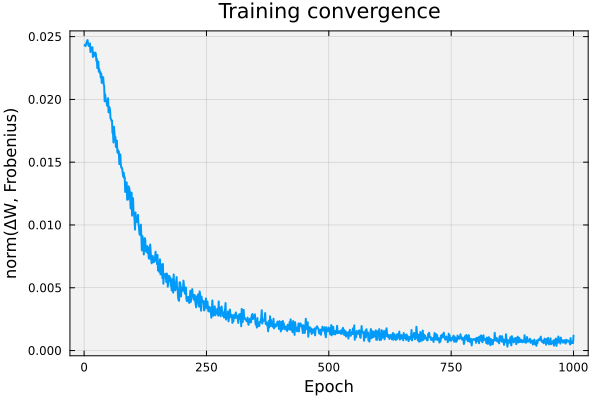

In [21]:
let
    plot(history;
        xlabel = "Epoch",
        ylabel = "norm(ΔW, Frobenius)",
        title = "Training convergence",
        legend = false,
        lw = 2,
    )

    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);
end

__After training__: Now let's see how training changed the distribution. We reuse the same enumeration logic on `trained_model` with $\beta = 1.0$.

> __What do we expect after training?__
>
> After training, the weight updates should have shifted the Boltzmann distribution so that the two training patterns $[-1,-1,1]$ and $[1,1,-1]$ have higher probability relative to the untrained model.

We enumerate all configurations and compute the partition function for `trained_model`.

In [22]:
P_after = let

    β_train = 1.0;  # use same β as training
    N = 2^number_of_nodes;
    Z_vals = Dict{Int,Float64}();

    for i ∈ 0:(N - 1)
        sᵢ = digits(i, base = 2, pad = number_of_nodes) |> x -> 2 .* x .- 1 |> reverse;
        Z_vals[i] = exp(-β_train * energy(trained_model, sᵢ));
    end

    Z̄ = sum(values(Z_vals));
    P_after = Dict(i => Z_vals[i] / Z̄ for i ∈ 0:(N - 1));
    @assert sum(values(P_after)) ≈ 1.0;
    P_after
end;

Let's compare the stationary distribution before and after training. The two training patterns are marked with an asterisk in the `trained` column.

> __What do we expect?__ After training, the two patterns $[-1,-1,1]$ and $[1,1,-1]$ should have higher probability in `P_after` than in `P_before`. The remaining six configurations should have correspondingly lower probability.

Do we see what we expect?

In [23]:
let
    N = 2^number_of_nodes;
    rows = NamedTuple[];
    training_patterns = [[-1, -1, 1], [1, 1, -1]];

    for i ∈ 0:(N - 1)
        sᵢ = digits(i, base = 2, pad = number_of_nodes) |> x -> 2 .* x .- 1 |> reverse;
        is_trained = any(sᵢ == p for p ∈ training_patterns) ? "*" : " ";
        push!(rows, (
            configuration = sᵢ,
            P_before = round(P_before[i]; digits = 4),
            P_after  = round(P_after[i];  digits = 4),
            trained  = is_trained,
        ));
    end

    pretty_table(rows;
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact),
    );
end

 --------------- ---------- --------- ---------
  configuration   P_before   P_after   trained 
 --------------- ---------- --------- ---------
   [-1, -1, -1]     0.1269    0.0009
    [-1, -1, 1]      0.125     0.482         *
    [-1, 1, -1]     0.1249    0.0009
     [-1, 1, 1]     0.1231    0.0009
    [1, -1, -1]     0.1231    0.0009
     [1, -1, 1]     0.1249    0.0009
     [1, 1, -1]      0.125    0.5127         *
      [1, 1, 1]     0.1269    0.0009
 --------------- ---------- --------- ---------


> __What does this result mean in practice?__ 
> 
> In this toy example, we trained on only two patterns, so the model moved most probability mass onto those two states. This is expected: Boltzmann training matches the model distribution to the data distribution.
>
> For larger systems, we do not enumerate all $2^N$ configurations. Instead, we estimate model statistics by sampling (for example Gibbs sampling / CD-style methods). But the same principle still holds: if the training data are narrow, the learned distribution will also be narrow. Better data coverage leads to broader, more representative models.

### Things to think about
* __Question__: From the `P_before` vs `P_after` table, how much probability mass shifts onto the two training patterns $[-1,-1,1]$ and $[1,1,-1]$ after training?

___

## Summary
This lab explored sampling and stationary distributions in a small Boltzmann machine.

> __Key Takeaways__
>
> * **Boltzmann distribution:** After sufficient sampling, the state configurations of a Boltzmann machine converge to a Boltzmann distribution where lower-energy states have higher probability. In practice, this means frequency tables from long runs should reflect the same ordering implied by the energy landscape.
> * **Partition function limitation:** Computing the exact stationary distribution requires summing over all $2^n$ configurations, which is intractable for large networks. For larger models, we therefore replace exact enumeration with sampling-based approximations.
> * **Training challenge:** Each training iteration requires sampling until the network reaches its stationary distribution, making training computationally expensive. This motivates architectures and algorithms that reduce or approximate the cost of the negative phase.

The need to reach stationarity at each training step motivates the development of restricted Boltzmann machines and contrastive divergence.
___